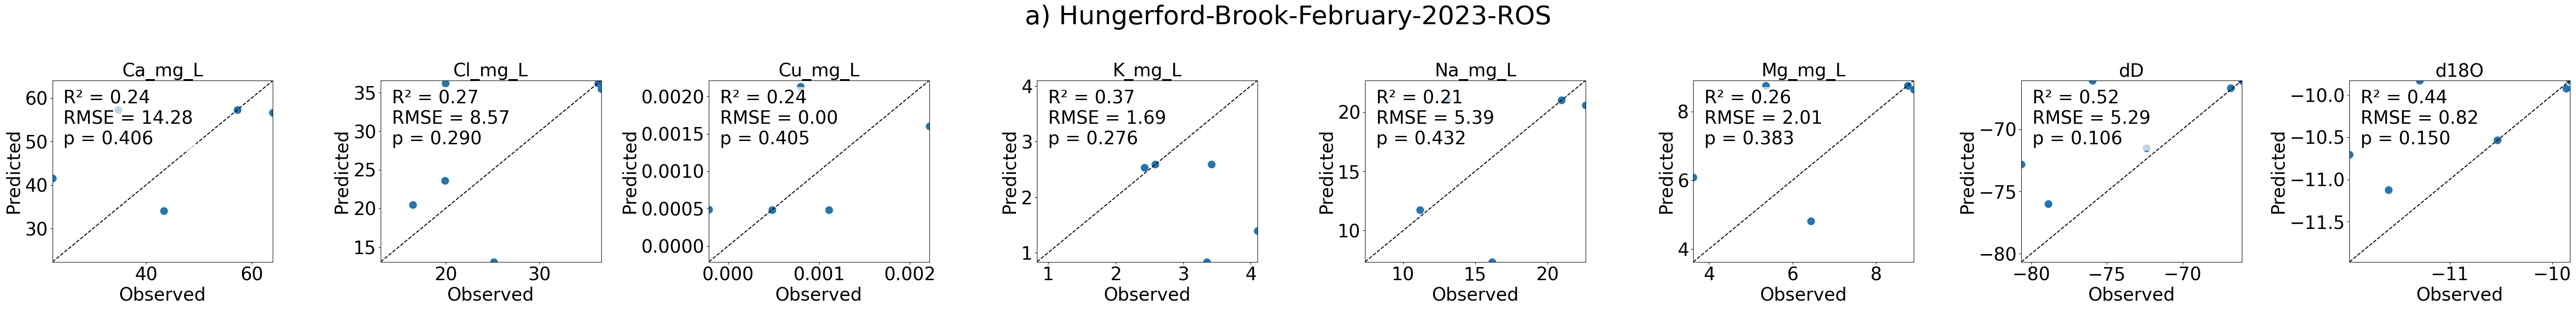

✅ Figure saved to output dir


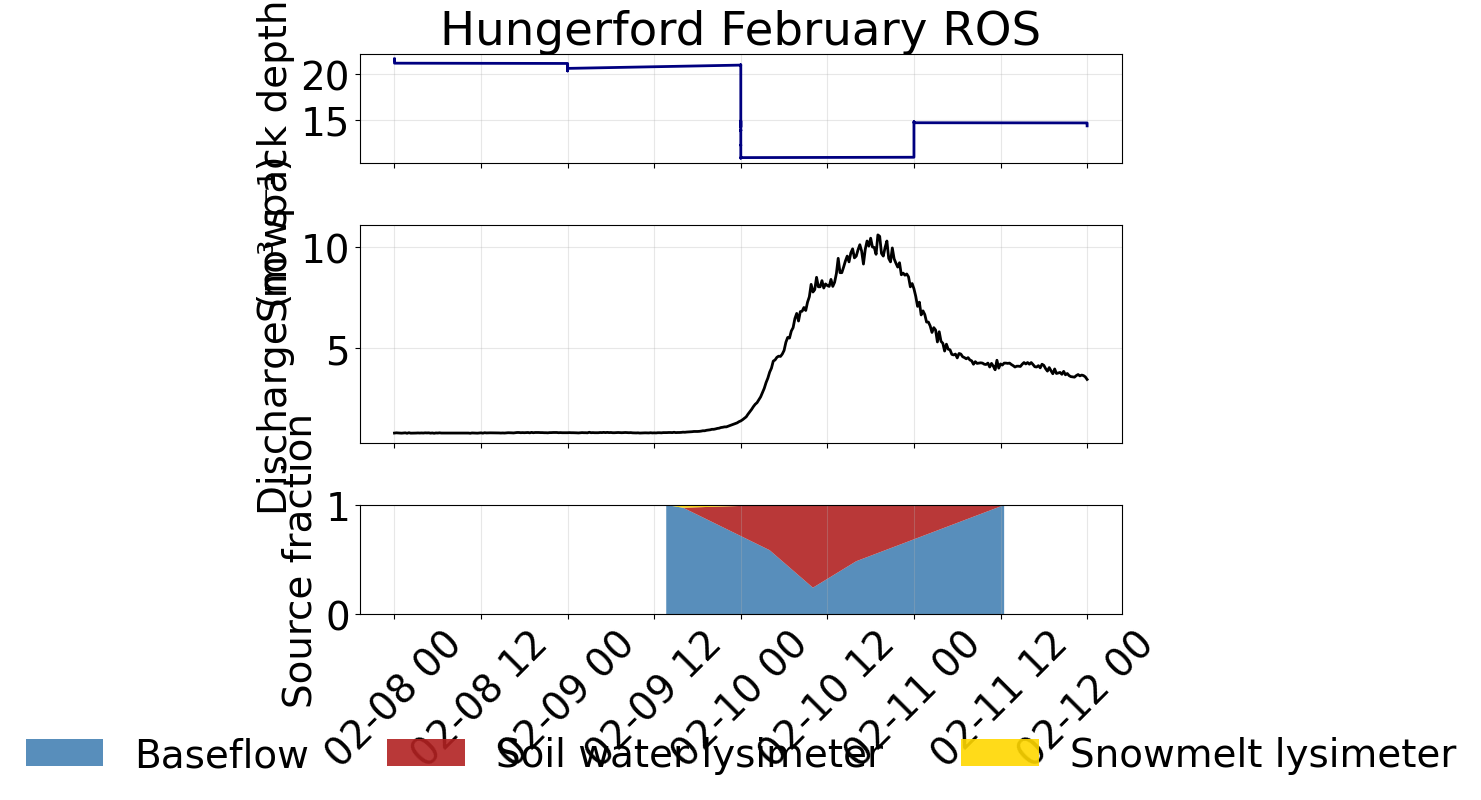

Saved fractions to EMMA-results


,Sample ID,Datetime,Site,Baseflow,Snowmelt lysimeter,Soil water lysimeter,Sum_Fractions
0,RI23-1004,2023-02-10 04:00:00,Hungerford,0.586263,0.000000e+00,4.137372e-01,1.0
1,RI23-1005,2023-02-10 10:00:00,Hungerford,0.242656,0.000000e+00,7.573443e-01,1.0
2,RI23-1007,2023-02-10 16:00:00,Hungerford,0.485255,1.999106e-15,5.147447e-01,1.0
3,RI23-1008,2023-02-11 12:30:00,Hungerford,1.000000,0.000000e+00,0.000000e+00,1.0
4,RI23-1001,2023-02-09 13:40:00,Hungerford,1.000000,0.000000e+00,4.996004e-16,1.0


In [4]:
import importlib
import sys
from pathlib import Path
import pandas as pd

# Set up home path and working repo dir 
HOME = Path.home()
repo_dir = HOME / "OneDrive/git-repos/LCBP-interannual-EMMAs"

if str(repo_dir) not in sys.path:
    sys.path.append(str(repo_dir))

# Import EMMA module
import EMMA.event_emma as em  
import EMMA.event_pca_error as ep
importlib.reload(ep)
importlib.reload(em)

# Define data directory using relative path logic
data_dir = repo_dir / "Data"

output_dir = repo_dir / "Output/EMMA-results/" 

# Load the full RI23 dataset
df = pd.read_csv(data_dir / "GrabSample_data/RI23-IC-ICP-isotope-toc-joined.csv")

#################
# FEB ROS at HB #
#################

hungerford_febros_fractions_df, hungerford_febros_scaler, hungerford_febros_pca, hungerford_febros_endmembers_df = em.run_emma_event(
    data=df,
    site="Hungerford",
    start_date="2023-02-08 00:00:00",
    end_date="2023-02-12 00:00:00",
    endmember_ids=[
                   "RI23-1001", # Baseflow 
                   "RI23-5003", # SWLD 02/15/2023
                   "RI23-5002"] # SML 02/15/2023
)

#hungerford_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O', 'Na_mg_L', 'Cl_mg_L'] # Original WRR submission tracers
hungerford_tracers = ['Ca_mg_L', 'Cl_mg_L', 'Cu_mg_L', 'K_mg_L', 'Na_mg_L', 'Mg_mg_L', 'dD', 'd18O'] # WRR resubmission tracers

# Call the prediction function
hungerford_febros_predicted = em.predict_tracers_from_fractions(
    fractions_df=hungerford_febros_fractions_df,
    endmembers_df=hungerford_febros_endmembers_df,
    tracer_cols=hungerford_tracers
)

# Plot observed vs predicted tracer values
em.plot_observed_vs_predicted(
    title="a) Hungerford-Brook-February-2023-ROS", 
    predicted_df=hungerford_febros_predicted, 
    stream_df=df, 
    tracer_cols=hungerford_tracers, 
    output_dir=output_dir
)

# Plot EMMA fractions with hydrograph and snowpack depth

# Plot EMMA fractions with hydrograph and snowpack depth
hungerford_febros_plot = em.plot_emma_fractions_with_hydrograph(
    fractions_df      = hungerford_febros_fractions_df,
    discharge_csv     = data_dir / "StreamSensor_data/Discharge.Discharge.NEWRnet@Hungerford_Brook.20221001.csv",
    start_date        = "2023-02-08 00:00:00",
    end_date          = "2023-02-12 00:00:00",
    site              = "Hungerford",
    discharge_time_col= "Timestamp (UTC-04:00)",
    discharge_value_col="Value",
    snowpack_csv      = data_dir / "Met_data/enf-noaa-precip-WYW23.csv",
    snowpack_time_col = "Date",
    snowpack_depth_col= "snowpack_cm",
    title             = "Hungerford February ROS"
)

# Save the EMMA fractions to EMMA-results directory

output_file_path = output_dir / "Hungerford_Feb_ROS_fractions.csv"
hungerford_febros_fractions_df.to_csv(output_file_path, index=False)

print(f"Saved fractions to EMMA-results")

hungerford_febros_fractions_df.head()

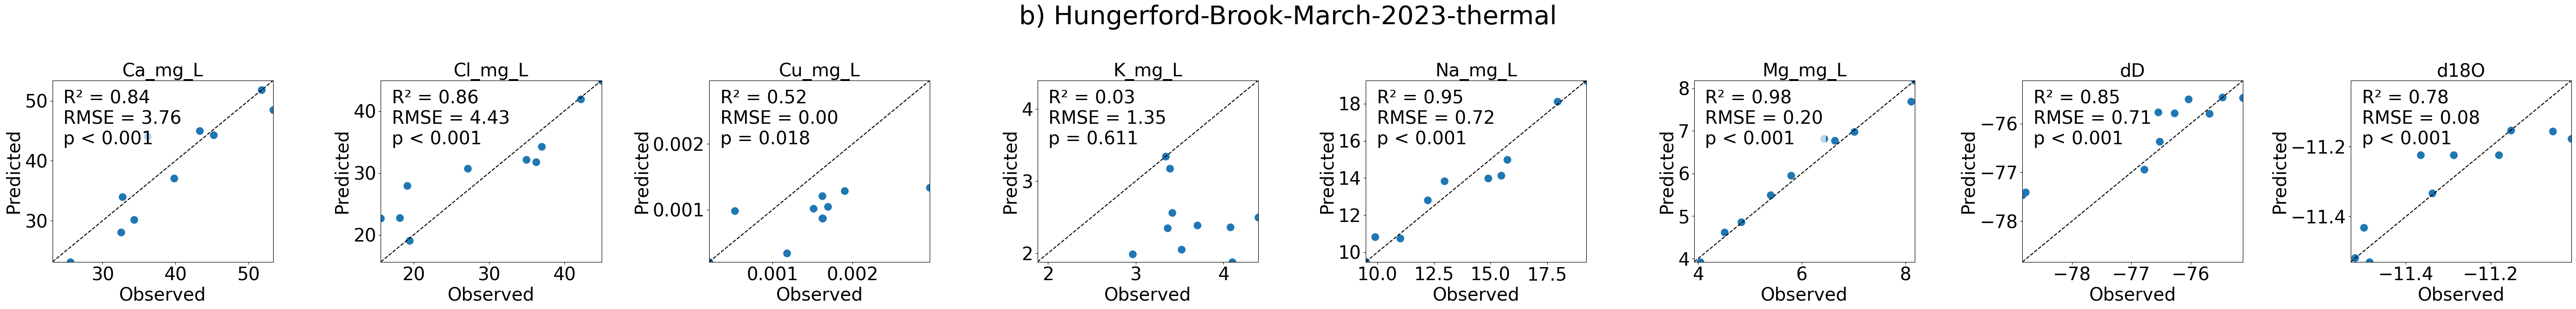

✅ Figure saved to output dir


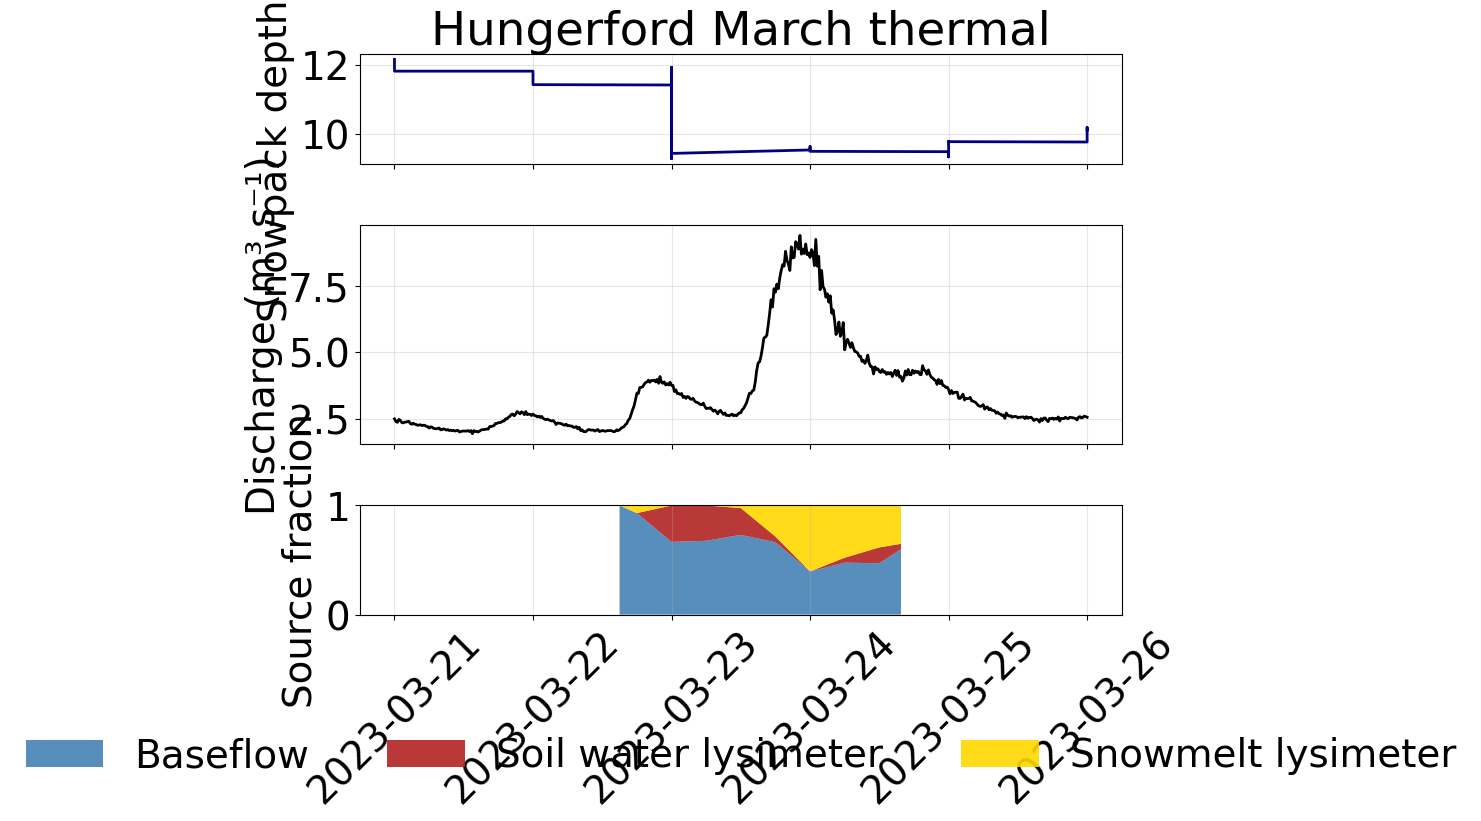

Saved fractions to EMMA-results


,Sample ID,Datetime,Site,Baseflow,Snowmelt lysimeter,Soil water lysimeter,Sum_Fractions
0,RI23-1035,2023-03-22 15:00:00,Hungerford,1.000000,7.160939e-15,8.160139e-15,1.0
1,RI23-1036,2023-03-22 18:00:00,Hungerford,0.930323,6.967694e-02,0.000000e+00,1.0
2,RI23-1037,2023-03-23 00:00:00,Hungerford,0.666576,1.043686e-14,3.334245e-01,1.0
3,RI23-1038,2023-03-23 06:00:00,Hungerford,0.676390,6.398332e-14,3.236097e-01,1.0
4,RI23-1042,2023-03-23 12:00:00,Hungerford,0.730678,2.337686e-02,2.459453e-01,1.0


In [5]:
import importlib
import sys
from pathlib import Path
import pandas as pd

# Set up home path and working repo dir 
HOME = Path.home()
repo_dir = HOME / "OneDrive/git-repos/LCBP-interannual-EMMAs"

if str(repo_dir) not in sys.path:
    sys.path.append(str(repo_dir))

# Import EMMA module
import EMMA.event_emma as em  
import EMMA.event_pca_error as ep
importlib.reload(ep)
importlib.reload(em)

# Define data directory using relative path logic
data_dir = repo_dir / "Data"

output_dir = repo_dir / "Output/EMMA-results/" 

# Load the full RI23 dataset
df = pd.read_csv(data_dir / "GrabSample_data/RI23-IC-ICP-isotope-toc-joined.csv")

#################
# MAR THM at HB #
#################

# Event B
# Hungerford March thermal event
# Potential endmembers: 
    # RI23-5008 Groundwater (Mark's well) 03/16/2023
    # RI20-HB-DGW-Mark-1 Mark's well 06/23/2020
    # RI22-0858 03/17/2022 Hungerford groundwater from Meghan (assume Mark's well)
    # RI22-0864 07/27/2022 Hungerford groundwater from Meghan (assume Mark's well)
    # RI23-1035 Baseflow 03/31/2023
    # RI23-1001 # Baseflow 02/09/2023 (labeled GW)
    # RI23-5007 Soil water lysimeter dry 03/16/2023
    # RI23-1061 Snowmelt lysimeter 03/28/2023

hungerford_martherm_fractions_df, hungerford_martherm_scaler, hungerford_martherm_pca, hungerford_martherm_endmembers_df = em.run_emma_event(
    data=df,
    site="Hungerford",
    start_date="2023-03-21 00:00:00",
    end_date="2023-03-26 00:00:00",
        endmember_ids=
                   [
                   #"RI23-1001", # Baseflow 02/09/2023
                   "RI23-1035", # 03/22/2023 Baseflow
                   #"RI23-5008", # Mark's well 2023
                   #"RI20-HB-DGW-Mark-1" # Mark's well 2020
                   #"RI22-0858", # Mark's well 03/17/2022
                   #"RI22-0864",
                   #"RI23-1085", #Baseflow 03/31/2023 removed for now
                   "RI23-5007", # SWLD
                   "RI23-1061"
                    ],  
)

#hungerford_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O', 'Na_mg_L', 'Cl_mg_L'] # Original WRR submission tracers
hungerford_tracers = ['Ca_mg_L', 'Cl_mg_L', 'Cu_mg_L', 'K_mg_L', 'Na_mg_L', 'Mg_mg_L', 'dD', 'd18O'] # WRR resubmission tracers

# Call the prediction function
hungerford_martherm_predicted = em.predict_tracers_from_fractions(
    fractions_df=hungerford_martherm_fractions_df,
    endmembers_df=hungerford_martherm_endmembers_df,
    tracer_cols=hungerford_tracers
)

# Plot observed vs predicted tracer values
em.plot_observed_vs_predicted(
    title = "b) Hungerford-Brook-March-2023-thermal", 
    predicted_df = hungerford_martherm_predicted, 
    stream_df = df, 
    tracer_cols = hungerford_tracers,
    output_dir=output_dir)

# Plot EMMA fractions with hydrograph and snowpack depth

# Plot EMMA fractions with hydrograph and snowpack depth
hungerford_martherm_plot = em.plot_emma_fractions_with_hydrograph(
    fractions_df      = hungerford_martherm_fractions_df,
    discharge_csv     = data_dir / "StreamSensor_data/Discharge.Discharge.NEWRnet@Hungerford_Brook.20221001.csv",
    start_date        = "2023-03-21 00:00:00",
    end_date          = "2023-03-26 00:00:00",
    site              = "Hungerford",
    discharge_time_col= "Timestamp (UTC-04:00)",
    discharge_value_col="Value",
    snowpack_csv      = data_dir / "Met_data/enf-noaa-precip-WYW23.csv",
    snowpack_time_col = "Date",
    snowpack_depth_col= "snowpack_cm",
    title             = "Hungerford March thermal"
)

# Save the EMMA fractions to EMMA-results directory

output_file_path = output_dir / "Hungerford_Mar_therm_fractions.csv"
hungerford_martherm_fractions_df.to_csv(output_file_path, index=False)

print(f"Saved fractions to EMMA-results")

hungerford_martherm_fractions_df.head()

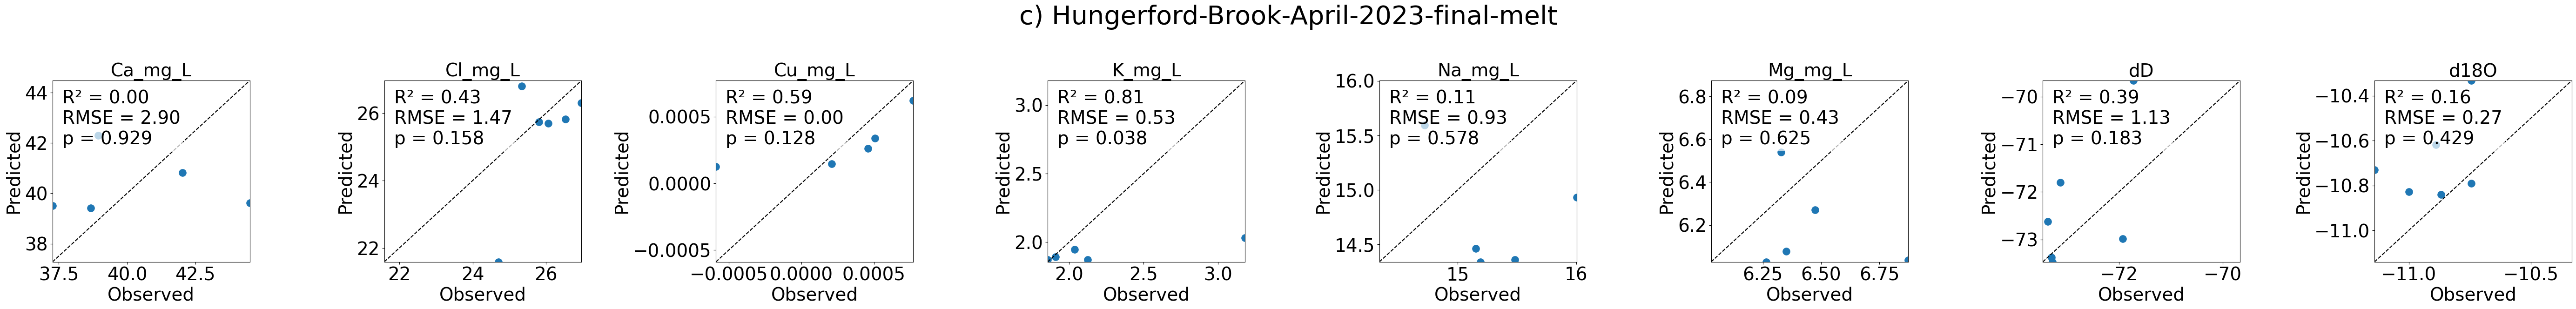

✅ Figure saved to output dir


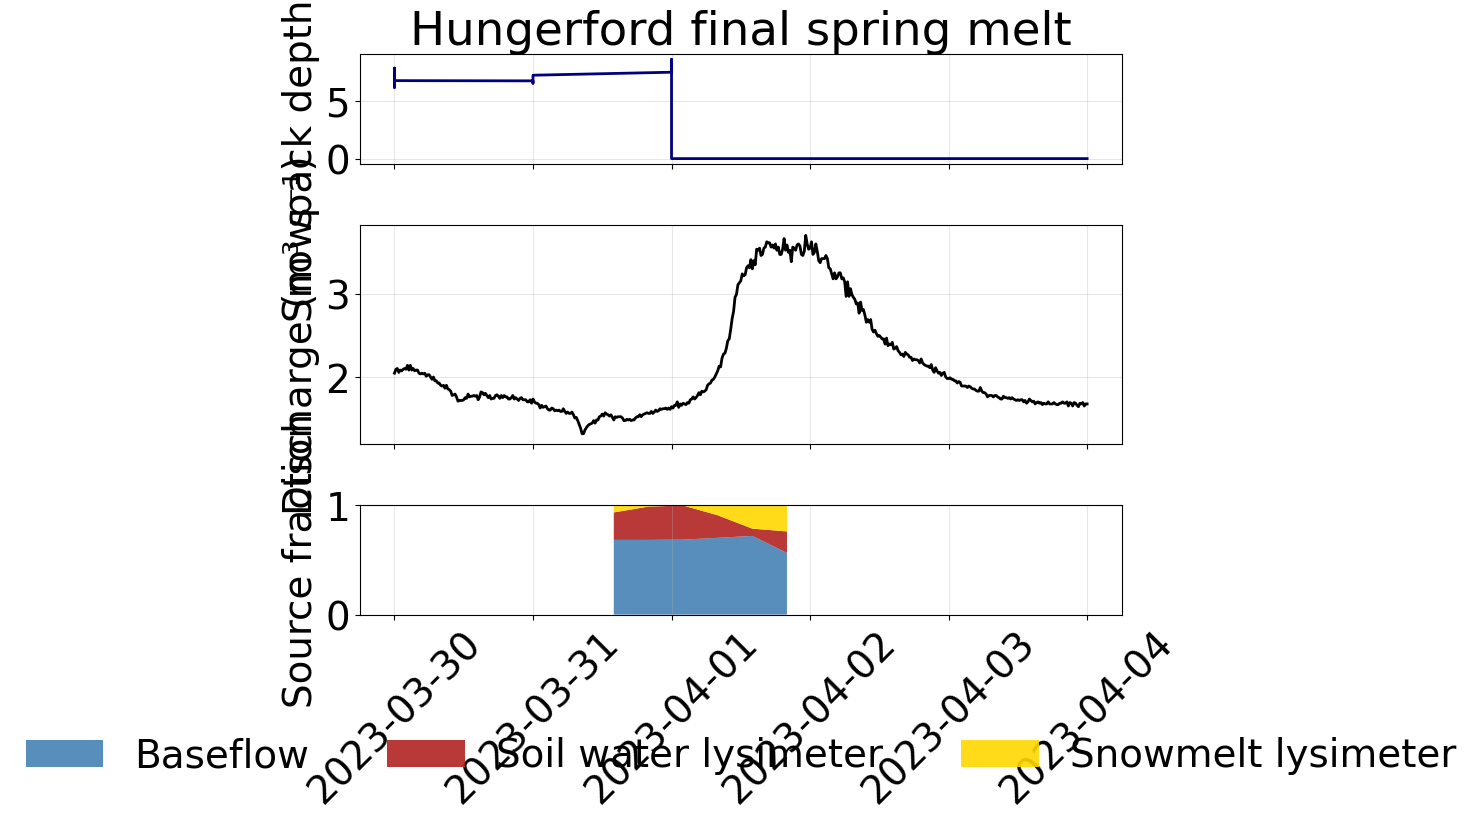

Saved fractions to EMMA-results


,Sample ID,Datetime,Site,Baseflow,Snowmelt lysimeter,Soil water lysimeter,Sum_Fractions
0,RI23-1085,2023-03-31 14:00:00,Hungerford,0.684559,6.364304e-02,0.251798,1.0
1,RI23-1086,2023-03-31 20:00:00,Hungerford,0.684772,1.029019e-02,0.304938,1.0
2,RI23-1087,2023-04-01 02:00:00,Hungerford,0.686955,1.487002e-13,0.313045,1.0
3,RI23-1088,2023-04-01 08:00:00,Hungerford,0.703818,8.970253e-02,0.206480,1.0
4,RI23-1089,2023-04-01 14:00:00,Hungerford,0.721186,2.123024e-01,0.066512,1.0


In [6]:
import importlib
import sys
from pathlib import Path
import pandas as pd

# Set up home path and working repo dir 
HOME = Path.home()
repo_dir = HOME / "OneDrive/git-repos/LCBP-interannual-EMMAs"

if str(repo_dir) not in sys.path:
    sys.path.append(str(repo_dir))

# Import EMMA module
import EMMA.event_emma as em  
import EMMA.event_pca_error as ep
importlib.reload(ep)
importlib.reload(em)

# Define data directory using relative path logic
data_dir = repo_dir / "Data"

output_dir = repo_dir / "Output/EMMA-results/" 

# Load the full RI23 dataset
df = pd.read_csv(data_dir / "GrabSample_data/RI23-IC-ICP-isotope-toc-joined.csv")

#################
# FRESHET at HB #
#################

# A. February ROS
# B. March thermal
# C. Final spring melt

# Hungerford April final spring melt
# Potential endmembers: 
    # RI23-5008 Groundwater (Mark's well) 03/16/2023
    # RI20-HB-DGW-Mark-1 Mark's well 06/23/2020
    # RI22-0858 03/17/2022 Hungerford groundwater from Meghan (assume Mark's well)
    # RI22-0864 07/27/2022 Hungerford groundwater from Meghan (assume Mark's well)
    # RI23-1035 Baseflow 03/31/2023
    # RI23-1001 # Baseflow 02/09/2023 (labeled GW)
    # RI23-5007 Soil water lysimeter dry 03/16/2023
    # RI23-1061 Snowmelt lysimeter 03/28/2023

hungerford_springmelt_fractions_df, hungerford_springmelt_scaler, hungerford_springmelt_pca, hungerford_springmelt_endmembers_df = em.run_emma_event(
    data=df,
    site="Hungerford",
    start_date="2023-03-30 00:00:00",
    end_date="2023-04-04 00:00:00",
    endmember_ids=[
                   "RI23-1001", # Baseflow 02/09/2023
                   #"RI23-1035", # 03/22/2023 Baseflow
                   #"RI23-1085", # Baseflow 03/31/23
                   #"RI23-5008", # Groundwater (Mark's well) 03/16/2023
                   #"RI20-HB-DGW-Mark-1" # Mark's well 2020
                   #"RI22-0858", # Mark's well 03/17/2022
                   #"RI22-0864", # Mark's well 07/27/2022
                   #"RI23-5014", # Soil water lysimeter dry 04/12/23
                   "RI23-5013", # Soil water lysimeter wet 04/12/23
                   "RI23-5017", # Snowmelt lysimeter 04/12/23
                   "RI23-1061" # Snowmelt lysimeter 03/28/23
                    ])

#hungerford_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O', 'Na_mg_L', 'Cl_mg_L'] # Original WRR submission tracers
hungerford_tracers = ['Ca_mg_L', 'Cl_mg_L', 'Cu_mg_L', 'K_mg_L', 'Na_mg_L', 'Mg_mg_L', 'dD', 'd18O'] # WRR resubmission tracers

# Call the prediction function
hungerford_springmelt_predicted = em.predict_tracers_from_fractions(
    fractions_df=hungerford_springmelt_fractions_df,
    endmembers_df=hungerford_springmelt_endmembers_df,
    tracer_cols=hungerford_tracers
)

# Plot observed vs predicted tracer values
em.plot_observed_vs_predicted(
    title = "c) Hungerford-Brook-April-2023-final-melt", 
    predicted_df = hungerford_springmelt_predicted, 
    stream_df = df, 
    tracer_cols = hungerford_tracers,
    output_dir=output_dir)

# Plot EMMA fractions with hydrograph and snowpack depth

# Plot EMMA fractions with hydrograph and snowpack depth
hungerford_springmelt_plot = em.plot_emma_fractions_with_hydrograph(
    fractions_df      = hungerford_springmelt_fractions_df,
    discharge_csv     = data_dir / "StreamSensor_data/Discharge.Discharge.NEWRnet@Hungerford_Brook.20221001.csv",
    start_date        = "2023-03-30 00:00:00",
    end_date          = "2023-04-04 00:00:00",
    site              = "Hungerford",
    discharge_time_col= "Timestamp (UTC-04:00)",
    discharge_value_col="Value",
    snowpack_csv      = data_dir / "Met_data/enf-noaa-precip-WYW23.csv",
    snowpack_time_col = "Date",
    snowpack_depth_col= "snowpack_cm",
    title             = "Hungerford final spring melt"
)

# Save the EMMA fractions to EMMA-results directory

output_file_path = output_dir / "Hungerford_spring_melt_fractions.csv"
hungerford_springmelt_fractions_df.to_csv(output_file_path, index=False)

print(f"Saved fractions to EMMA-results")

#output_dir
hungerford_springmelt_fractions_df.head()